In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Connect to MySQL
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='root123',
    database='ecommerce'
)

# Load all tables into pandas dataframes
orders = pd.read_sql("SELECT * FROM orders", conn)
customers = pd.read_sql("SELECT * FROM customers", conn)
order_items = pd.read_sql("SELECT * FROM order_items", conn)
order_payments = pd.read_sql("SELECT * FROM order_payments", conn)
products = pd.read_sql("SELECT * FROM products", conn)
category_translation = pd.read_sql("SELECT * FROM category_translation", conn)

conn.close()

print("All tables loaded successfully!")
print(f"Orders: {orders.shape}")
print(f"Customers: {customers.shape}")
print(f"Order Items: {order_items.shape}")
print(f"Order Payments: {order_payments.shape}")
print(f"Products: {products.shape}")
print(f"Category Translation: {category_translation.shape}")

C:\Users\venisa\AppData\Local\Temp\ipykernel_20180\559336738.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  orders = pd.read_sql("SELECT * FROM orders", conn)
C:\Users\venisa\AppData\Local\Temp\ipykernel_20180\559336738.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  customers = pd.read_sql("SELECT * FROM customers", conn)
C:\Users\venisa\AppData\Local\Temp\ipykernel_20180\559336738.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  order_items = pd.read_sql("SELECT * FROM order_items", conn)
C:\Users\venisa\Ap

All tables loaded successfully!
Orders: (99441, 8)
Customers: (99441, 5)
Order Items: (112650, 7)
Order Payments: (103886, 5)
Products: (32951, 9)
Category Translation: (71, 2)


C:\Users\venisa\AppData\Local\Temp\ipykernel_20180\559336738.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  category_translation = pd.read_sql("SELECT * FROM category_translation", conn)


In [3]:
# Convert date columns to proper datetime format
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

# Convert payment_value to numeric
order_payments['payment_value'] = pd.to_numeric(order_payments['payment_value'])

# Check for missing values
print("Missing values per table:")
print("\nOrders:")
print(orders.isnull().sum())
print("\nOrder Payments:")
print(order_payments.isnull().sum())

print("\n Data cleaning complete!")

Missing values per table:

Orders:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Order Payments:
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

 Data cleaning complete!


In [4]:
# Drop rows where delivery date is missing (cancelled/undelivered orders)
orders_clean = orders.dropna(subset=['order_delivered_customer_date'])

# Fill missing approval dates with purchase timestamp
orders_clean = orders_clean.copy()
orders_clean['order_approved_at'] = orders_clean['order_approved_at'].fillna(orders_clean['order_purchase_timestamp'])

print(f"Original orders: {len(orders)}")
print(f"Clean orders: {len(orders_clean)}")
print(f"Removed rows: {len(orders) - len(orders_clean)}")
print("\n Missing values handled!")

Original orders: 99441
Clean orders: 96476
Removed rows: 2965

 Missing values handled!


In [5]:
# Merge orders with payments
orders_payments = orders_clean.merge(order_payments, on='order_id', how='inner')

# Extract year and month
orders_payments['year_month'] = orders_payments['order_purchase_timestamp'].dt.to_period('M')
orders_payments['year'] = orders_payments['order_purchase_timestamp'].dt.year
orders_payments['quarter'] = orders_payments['order_purchase_timestamp'].dt.quarter

# Monthly revenue
monthly_revenue = orders_payments.groupby('year_month')['payment_value'].sum().reset_index()
monthly_revenue.columns = ['year_month', 'revenue']
monthly_revenue['year_month'] = monthly_revenue['year_month'].astype(str)

print("Monthly Revenue Summary:")
print(monthly_revenue.tail(10))
print("\n Monthly revenue calculated!")

Monthly Revenue Summary:
   year_month     revenue
12    2017-11  1153393.22
13    2017-12   843199.17
14    2018-01  1078606.86
15    2018-02   966554.97
16    2018-03  1120678.00
17    2018-04  1132933.95
18    2018-05  1128836.69
19    2018-06  1011561.35
20    2018-07  1027383.10
21    2018-08   985414.28

 Monthly revenue calculated!


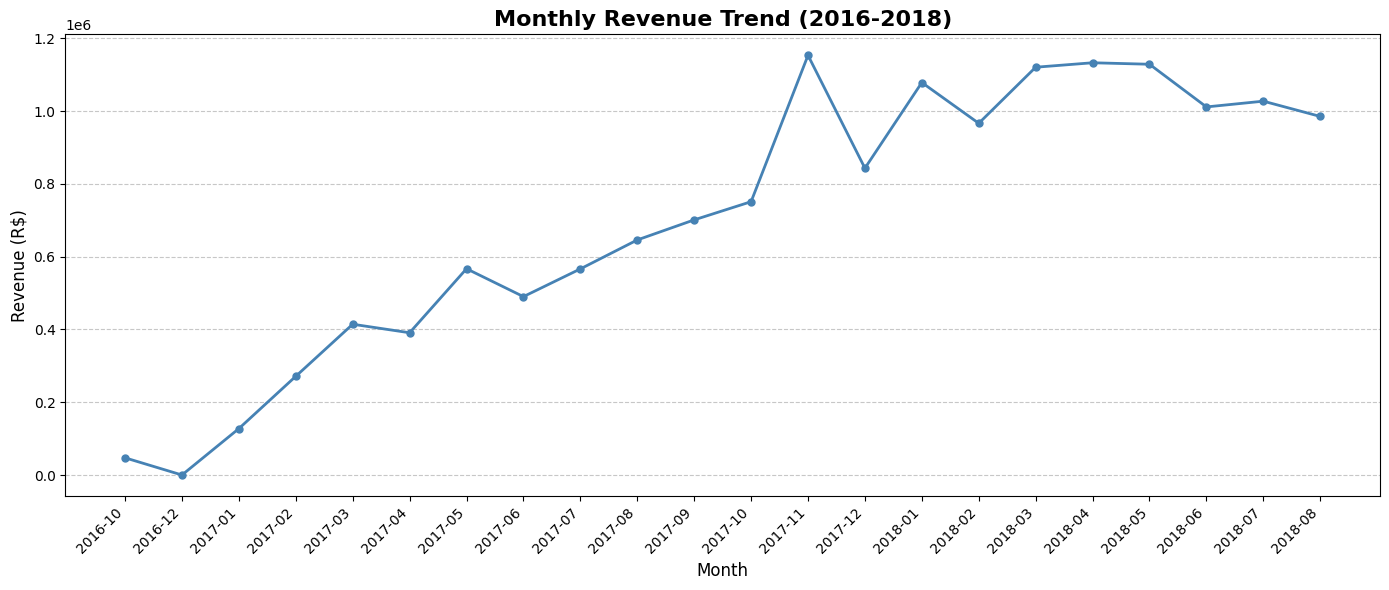

 Chart saved!


In [6]:
plt.figure(figsize=(14, 6))
plt.plot(monthly_revenue['year_month'], monthly_revenue['revenue'], 
         marker='o', color='steelblue', linewidth=2, markersize=5)

plt.title('Monthly Revenue Trend (2016-2018)', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue (R$)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('C:/ecommerce_project/monthly_revenue.png', dpi=150)
plt.show()

print(" Chart saved!")

In [7]:
# Merge orders with customers
orders_customers = orders_clean.merge(customers, on='customer_id', how='inner')

# Add quarter column
orders_customers['quarter'] = orders_customers['order_purchase_timestamp'].dt.to_period('Q')

# Count orders per zip code (proxy for same customer)
zip_order_counts = orders_customers.groupby('customer_zip_code_prefix')['order_id'].count().reset_index()
zip_order_counts.columns = ['customer_zip_code_prefix', 'total_orders']

# Merge back
orders_customers = orders_customers.merge(zip_order_counts, on='customer_zip_code_prefix', how='inner')

# Cohort analysis per quarter
cohort = orders_customers.groupby('quarter').agg(
    total_customers=('customer_zip_code_prefix', 'nunique'),
    repeat_customers=('total_orders', lambda x: (x > 1).sum())
).reset_index()

cohort['repeat_rate'] = (cohort['repeat_customers'] / cohort['total_customers'] * 100).round(2)
cohort['quarter'] = cohort['quarter'].astype(str)

print(cohort)
print("\n Cohort analysis complete!")

  quarter  total_customers  repeat_customers  repeat_rate
0  2016Q3                1                 1       100.00
1  2016Q4              267               268       100.37
2  2017Q1             3576              4756       133.00
3  2017Q2             5493              8677       157.96
4  2017Q3             6616             11811       178.52
5  2017Q4             8038             16734       208.19
6  2018Q1             8810             19997       226.98
7  2018Q2             8560             19084       222.94
8  2018Q3             6790             12107       178.31

 Cohort analysis complete!


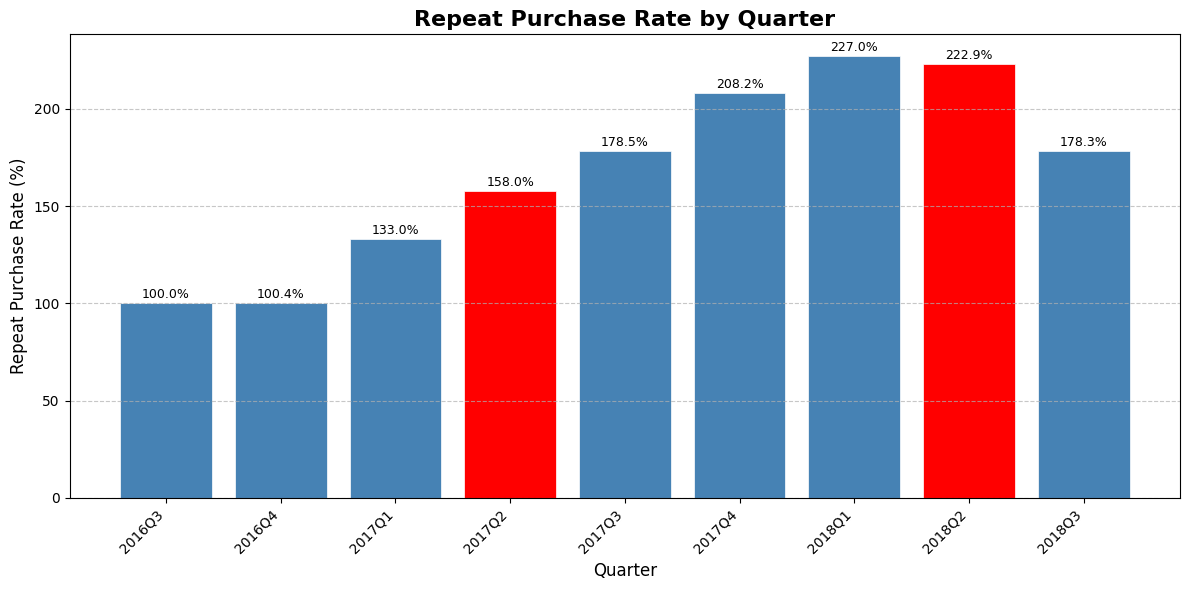

Cohort chart saved!


In [8]:
plt.figure(figsize=(12, 6))
bars = plt.bar(cohort['quarter'], cohort['repeat_rate'], 
               color=['steelblue' if 'Q2' not in q else 'red' for q in cohort['quarter']],
               edgecolor='white', linewidth=0.5)

plt.title('Repeat Purchase Rate by Quarter', fontsize=16, fontweight='bold')
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Repeat Purchase Rate (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on bars
for bar, val in zip(bars, cohort['repeat_rate']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('C:/ecommerce_project/cohort_analysis.png', dpi=150)
plt.show()

print("Cohort chart saved!")

C:\Users\venisa\AppData\Local\Temp\ipykernel_20180\340545943.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_categories, x='revenue', y='category', palette='Blues_r')


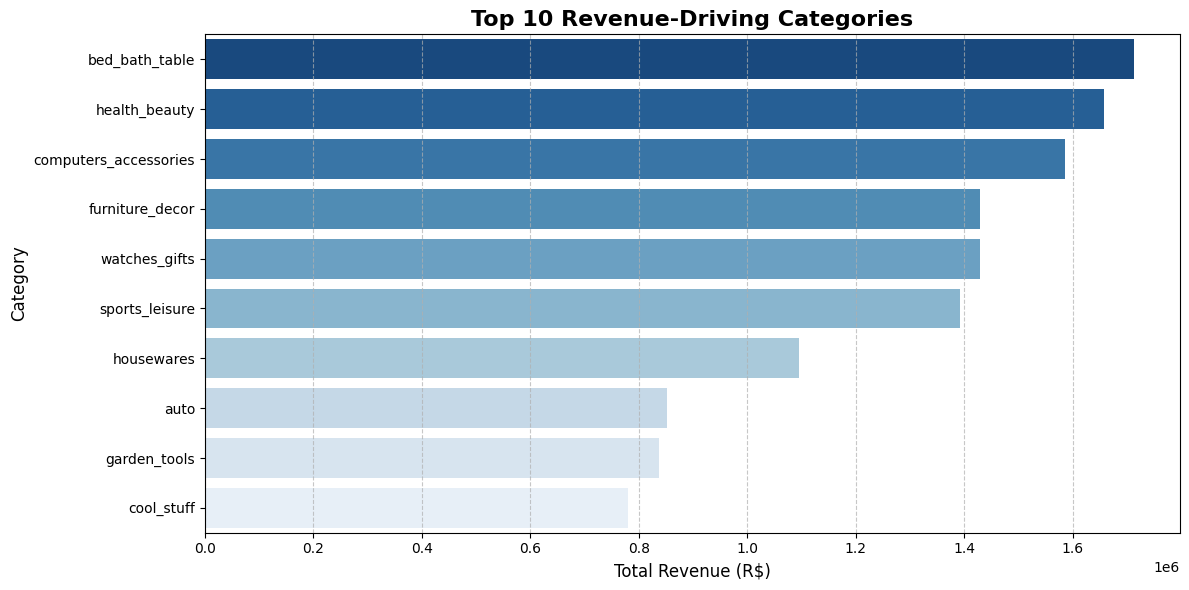

 Top categories chart saved!


In [9]:
# Merge order_items with products and category_translation
items_products = order_items.merge(products, on='product_id', how='inner')
items_products = items_products.merge(category_translation, on='product_category_name', how='inner')
items_payments = items_products.merge(order_payments, on='order_id', how='inner')

# Top 10 categories by revenue
top_categories = items_payments.groupby('product_category_name_english')['payment_value'].sum().reset_index()
top_categories.columns = ['category', 'revenue']
top_categories = top_categories.sort_values('revenue', ascending=False).head(10)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=top_categories, x='revenue', y='category', palette='Blues_r')
plt.title('Top 10 Revenue-Driving Categories', fontsize=16, fontweight='bold')
plt.xlabel('Total Revenue (R$)', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('C:/ecommerce_project/top_categories.png', dpi=150)
plt.show()

print(" Top categories chart saved!")

C:\Users\venisa\AppData\Local\Temp\ipykernel_20180\1603750508.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_states, x='state', y='revenue', palette='Greens_r')


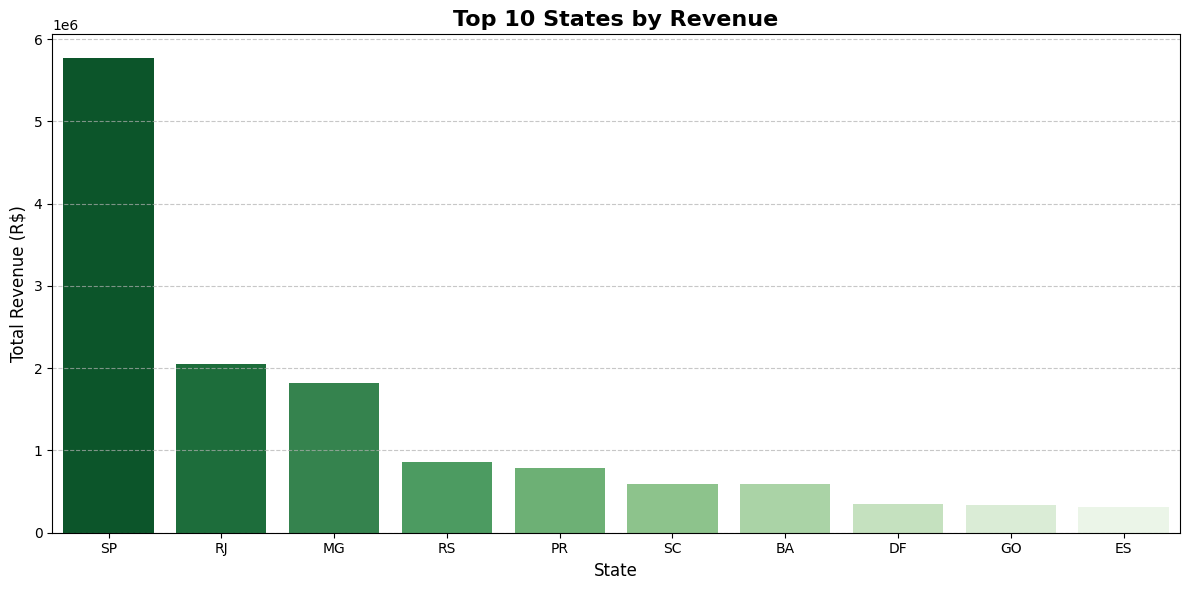

 Regional revenue chart saved!


In [10]:
# Merge orders with customers and payments
regional = orders_clean.merge(customers, on='customer_id', how='inner')
regional = regional.merge(order_payments, on='order_id', how='inner')

# Top 10 states by revenue
top_states = regional.groupby('customer_state')['payment_value'].sum().reset_index()
top_states.columns = ['state', 'revenue']
top_states = top_states.sort_values('revenue', ascending=False).head(10)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=top_states, x='state', y='revenue', palette='Greens_r')
plt.title('Top 10 States by Revenue', fontsize=16, fontweight='bold')
plt.xlabel('State', fontsize=12)
plt.ylabel('Total Revenue (R$)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('C:/ecommerce_project/regional_revenue.png', dpi=150)
plt.show()

print(" Regional revenue chart saved!")

In [11]:
# Export data for Tableau
# 1. Monthly Revenue
monthly_revenue.to_csv('C:/ecommerce_project/tableau_monthly_revenue.csv', index=False)

# 2. Top Categories
top_categories.to_csv('C:/ecommerce_project/tableau_top_categories.csv', index=False)

# 3. Regional Revenue
top_states.to_csv('C:/ecommerce_project/tableau_regional_revenue.csv', index=False)

# 4. Cohort Analysis
cohort.to_csv('C:/ecommerce_project/tableau_cohort.csv', index=False)

print(" All CSV files exported for Tableau!")

 All CSV files exported for Tableau!
